In [ ]:
from jax import config

config.update("jax_enable_x64", True)
import os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import jax
import jax.numpy as jnp
from jax import jit, random, lax, vmap, grad
import argparse
from tqdm import tqdm

from scipy.optimize import fsolve, minimize, curve_fit
from scipy.interpolate import CubicSpline, splrep, splev, UnivariateSpline
from scipy.signal import savgol_filter

from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams.update(
    {
        "mathtext.fontset": "stix",
        "font.family": "STIXGeneral",
        "legend.fontsize": 16,  # this is the font size in legends
        "xtick.labelsize": 16,  # this and next are the font of ticks
        "ytick.labelsize": 16,
        "axes.titlesize": 18,
        "axes.labelsize": 24,  # this is the fonx of axes labels
        "savefig.format": "pdf",  # how figures should be saved
        "legend.edgecolor": "0.0",
        "legend.framealpha": 1.0,
        # "text.usetex": True,
    }
)

plasmamap = plt.get_cmap("plasma")
virimap = plt.cm.viridis

In [49]:
import importlib
import sys
from pathlib import Path

# If notebook is in figures/, add ../src to Python path
sys.path.insert(0, str((Path.cwd().parent / "src").resolve()))

import curved_tubule_one_side_v1 as curve_pde

importlib.reload(curve_pde)

<module 'curved_tubule_one_side_v1' from '/Users/qiweiyu/Princeton Dropbox/Qiwei Yu/Projects_active/tether_wetting/code/tether_github/src/curved_tubule_one_side_v1.py'>

In [50]:
parser = argparse.ArgumentParser(description="ZTS_radial_v1_debug")

# parameters for the grid
parser.add_argument("--Lx", type=float, default=30, help="radial domain size")
parser.add_argument("--Lr1", type=float, default=1, help="vertical domain size")
parser.add_argument("--Lr2", type=float, default=15, help="vertical domain size")
parser.add_argument(
    "--nx", type=int, default=128, help="number of points in the radial direction"
)
parser.add_argument(
    "--nr", type=int, default=64, help="number of points in the vertical direction"
)

# interaction parameters
parser.add_argument(
    "--chi-psi", type=float, default=0.0, help="chi parameter for psi (membrane)"
)
parser.add_argument(
    "--chi-phi", type=float, default=2.5, help="chi parameter for phi (bulk)"
)
parser.add_argument(
    "--lmda-phi", type=float, default=1.0, help="gradient coefficient for phi (bulk)"
)
parser.add_argument(
    "--lmda-psi",
    type=float,
    default=1.0,
    help="gradient coefficient for psi (membrane)",
)
parser.add_argument(
    "--h0",
    type=float,
    default=-0.20,
    help="coupling coefficient between phi and the bare membrane",
)
parser.add_argument(
    "--h-phi-psi",
    type=float,
    default=1.0,
    help="coupling coefficient between phi and psi",
)

# mobility coefficients
parser.add_argument(
    "--m-phi", type=float, default=1.0, help="mobility coefficient for phi"
)
parser.add_argument(
    "--m-psi", type=float, default=1.0, help="mobility coefficient for psi"
)
parser.add_argument("--dt", type=float, default=1e-4 / 4, help="time step size")


# bulk tether concentration
parser.add_argument(
    "--psi-bulk", type=float, default=0.05, help="bulk tether concentration"
)

# initial conditions
parser.add_argument(
    "--init-x-center",
    type=float,
    default=20,
    help="x center of the initial droplet",
)
parser.add_argument(
    "--init-z-center",
    type=float,
    default=4,
    help="z center of the initial droplet",
)
parser.add_argument(
    "--init-radius", type=float, default=3, help="radius of the initial droplet"
)

# shape of the lower wall to use
parser.add_argument(
    "--lower-wall-fun",
    type=int,
    default=1,
    help="which lower wall function to use",
)
parser.add_argument(
    "--z0", type=float, default=0.5, help="z0 parameter for lower wall function"
)
parser.add_argument(
    "--z1", type=float, default=4.0, help="z1 parameter for lower wall function"
)
parser.add_argument(
    "--w", type=float, default=5.0, help="w parameter for lower wall function"
)

## number of steps
parser.add_argument("--num-epoch", type=int, default=300, help="number of epochs")
parser.add_argument(
    "--steps-per-epoch", type=int, default=100000, help="number of steps per epoch"
)

parser.add_argument(
    "--init-profile",
    type=str,
    default=None,
    help="initial profile for phi",
)

parser.add_argument(
    "--outputdir",
    type=str,
    default="data_curved_tubule_one_side_v1_3/",
    help="output directory",
)
flags = parser.parse_args("")

In [51]:
chi_psi, chi_phi = flags.chi_psi, flags.chi_phi
lmda_phi, lmda_psi = flags.lmda_phi, flags.lmda_psi
h0, h_phi_psi = flags.h0, flags.h_phi_psi
M_phi, M_psi = flags.m_phi, flags.m_psi
psi_boundary = flags.psi_bulk

In [52]:
phi_mesh = np.linspace(0, 1, 100)
f_phi_mesh = curve_pde.calc_f_uniform(phi_mesh, chi_phi)
phi_binodal, phi_spinodal = curve_pde.calc_binodal_spinodal(phi_mesh, f_phi_mesh)
phi_boundary = min(phi_binodal)
phi_binodal_center = (phi_binodal[0] + phi_binodal[1]) / 2

In [53]:
output_foldername_summary = "fig3/"
os.system(f"mkdir -p {output_foldername_summary}")

0

In [54]:
data_surface_tension = np.load("../data/chi_phi_2.5_surface_tension.npz")
sigma_lg = data_surface_tension["sigma_lg"]

In [55]:
psi_l_fun = (
    lambda psi_g: psi_g
    * np.exp(h_phi_psi * (phi_binodal[1] - phi_binodal[0]))
    / (1 + psi_g * (np.exp(h_phi_psi * (phi_binodal[1] - phi_binodal[0])) - 1))
)

psi_g = flags.psi_bulk
psi_l = psi_l_fun(psi_g)

# Define the boundary and solver

In [56]:
def lower_wall_7(x, z0=0.5, z1=4.0):
    return z0 + z1 * x / flags.Lx


z0 = flags.Lr1 + 0.5
z1 = 2

lower_wall = lambda x, z0=z0, z1=z1: lower_wall_7(x, z0=z0, z1=z1)

In [57]:
flags.dt = 2e-5
PhaseFieldSys = curve_pde.PhaseFieldSimulator(
    Lx=flags.Lx,
    Lr1=flags.Lr1,
    Lr2=flags.Lr2,
    nx=flags.nx,
    nr=flags.nr,
    chi_psi=chi_psi,
    chi_phi=chi_phi,
    lmda_phi=lmda_phi,
    lmda_psi=lmda_psi,
    h0=h0,
    h1=h_phi_psi,
    M_phi=M_phi,
    M_psi=M_psi,
    psi_boundary=psi_g,
    dt=flags.dt,
    wall=lower_wall,
)

In [58]:
def calc_com_cylindrical(phi, PhaseFieldSys):
    xsum = np.nansum(
        phi
        * PhaseFieldSys.vol_frac
        * PhaseFieldSys.x_c[:, None]
        * PhaseFieldSys.mask_inside
        * PhaseFieldSys.r_c[None, :]  # weight by r in cylindrical coordinates
    )
    rsum = np.nansum(
        phi
        * PhaseFieldSys.vol_frac
        * PhaseFieldSys.r_c[None, :]
        * PhaseFieldSys.mask_inside
        * PhaseFieldSys.r_c[None, :]  # weight by r in cylindrical coordinates
    )
    phisum = np.nansum(
        phi
        * PhaseFieldSys.vol_frac
        * PhaseFieldSys.mask_inside
        * PhaseFieldSys.r_c[None, :]
    )
    return xsum / phisum, rsum / phisum

# Load simulation results

In [59]:
psi_g_list = (1 + np.arange(5)) * 0.05
psi_l_list = psi_l_fun(psi_g_list)


h0 = -0.20
psi_g_mesh = np.linspace(0, 0.31, 100)[1:]
sigma_1_mesh = np.log(
    (1 + psi_g_mesh * (np.exp(h_phi_psi * (phi_binodal[1] - phi_binodal[0])) - 1))
)
cos_theta_mesh = (h0 * (phi_binodal[1] - phi_binodal[0]) + sigma_1_mesh) / sigma_lg
cos_theta_mesh = np.clip(cos_theta_mesh, -1, 1)

cos_theta_list = np.interp(psi_g_list, psi_g_mesh, cos_theta_mesh)

In [60]:
h0_mobile = -0.20
h1_mobile = h_phi_psi

# plotted for the paper
M_psi_list = np.array([0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1, 1.0])

# full list
M_psi_list = np.array(
    [0.0001, 0.0003, 0.0005, 0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1, 1.0]
)

In [61]:
def data_foldername_fun(psi_g, h0, h1, M_psi):
    outputdir = f"../data/data_curved_tubule_one_side_v1_3_long/psi_g_{psi_g:.2f}/"
    if M_psi < 0.001:
        decimal_M_psi = int(np.ceil(-np.log10(M_psi + 1e-12)))
        input_foldername = (
            outputdir
            + f"/chi_psi_{chi_psi}_chi_phi_{chi_phi}_h0_{h0}_h1_{h1}/"
            + f"psi_{psi_g:.3f}_mpsi_{M_psi:.0{decimal_M_psi}f}/"
        )
    else:
        input_foldername = (
            outputdir
            + f"/chi_psi_{chi_psi}_chi_phi_{chi_phi}_h0_{h0}_h1_{h1}/"
            + f"psi_{psi_g:.3f}_mpsi_{M_psi:.3f}/"
        )
    return input_foldername


data_trace_mobile_all = []

for psi_g_id in range(len(psi_g_list)):
    data_trace_mobile_all.append(
        [
            np.load(
                data_foldername_fun(psi_g_list[psi_g_id], h0_mobile, h1_mobile, M_psi)
                + "trace.npz",
                allow_pickle=True,
            )
            for M_psi in M_psi_list
        ]
    )

In [62]:
phi_threshold = (phi_binodal[0] + phi_binodal[1]) / 2
trace_data_mobile = []

for psi_g_id in range(len(psi_g_list)):
    t = []
    for m_id in range(len(M_psi_list)):
        phi_trace_mobile = data_trace_mobile_all[psi_g_id][m_id]["phi_trace"]
        com_trace = np.array(
            [
                calc_com_cylindrical(np.maximum(phi - phi_threshold, 0), PhaseFieldSys)
                for phi in phi_trace_mobile
            ]
        )
        t.append(
            {
                "t_trace": data_trace_mobile_all[psi_g_id][m_id]["t_trace"],
                "com_trace": com_trace,
            }
        )
    trace_data_mobile.append(t)

# Analyze velocity

In [63]:
# produce colormap in logscale of mobility
from matplotlib import colors as mcolors

norm = mcolors.Normalize(vmin=psi_g_list.min(), vmax=psi_g_list.max())
cmap = plt.cm.viridis
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # only needed for older matplotlib versions

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_87569/2618092808.py:10: SyntaxWarning: invalid escape sequence '\p'
  label=f"$\psi_\mathrm{{dil}}={psi_g_list[psi_g_id]:.2f}$",


Plotting trace for M_psi = 1.000


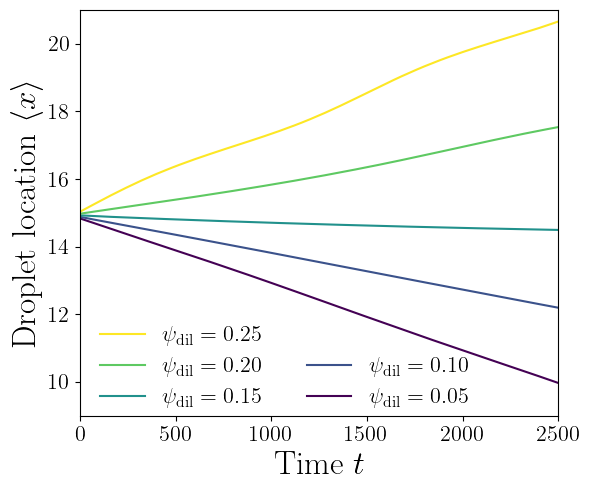

In [64]:
m_id = len(M_psi_list) - 1  # largest mobility
print(f"Plotting trace for M_psi = {M_psi_list[m_id]:.3f}")

fig, ax = plt.subplots(figsize=(6, 5), tight_layout=True)
for psi_g_id in range(len(psi_g_list)):
    trace_data = trace_data_mobile[psi_g_id][m_id]
    ax.plot(
        trace_data["t_trace"],
        trace_data["com_trace"][:, 0],
        label=f"$\psi_\mathrm{{dil}}={psi_g_list[psi_g_id]:.2f}$",
        color=cmap(norm(psi_g_list[psi_g_id])),
    )


handles, labels = ax.get_legend_handles_labels()
handles, labels = handles[::-1], labels[::-1]

ncol = 2
while len(labels) % ncol != 0:
    insert_location = len(labels) // ncol * ncol - 1
    handles.insert(
        insert_location, plt.Line2D([], [], linestyle="None", marker=None, color="none")
    )
    labels.insert(insert_location, "")  # empty label

ax.legend(
    handles, labels, frameon=False, ncol=2, loc="lower left", bbox_to_anchor=(0, -0.03)
)
ax.set_xlim(0, None)
ax.set_xlabel("Time $t$")
ax.set_ylabel(r"Droplet location $\langle x \rangle$")

ax.set_xlim(0, 2500)
ax.set_ylim(9, 21)

fig.savefig(output_foldername_summary + f"Fig3B.pdf")

In [65]:
M_psi_plot_list = np.array([0.001, 0.003, 0.005, 0.01, 0.03, 0.1, 1.0])
M_psi_plot = np.isin(M_psi_list, M_psi_plot_list)

# produce colormap in logscale of mobility
from matplotlib import colors as mcolors

norm = mcolors.Normalize(
    vmin=np.log10(M_psi_plot_list).min(), vmax=np.log10(M_psi_plot_list).max()
)
cmap = plt.cm.viridis_r
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # only needed for older matplotlib versions

Using psi_g = 0.1


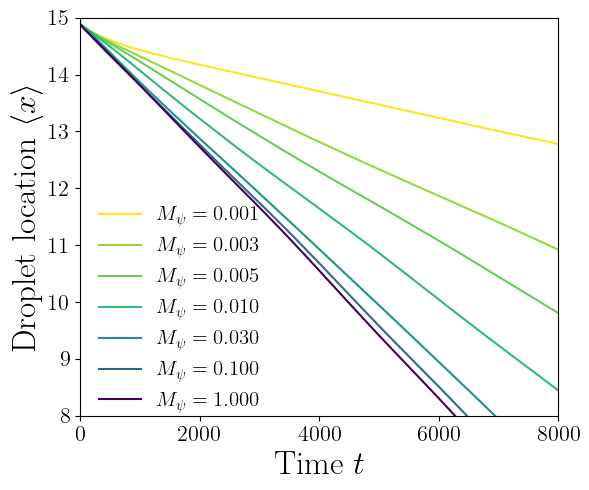

In [66]:
psi_g_id = 1
print("Using psi_g =", psi_g_list[psi_g_id])

tmax = 4000
xmax = 20

fig, ax = plt.subplots(figsize=(6, 5), tight_layout=True)
for m_id in range(len(M_psi_list)):
    if not M_psi_plot[m_id]:
        continue
    trace_data = trace_data_mobile[psi_g_id][m_id]
    xdata, ydata = trace_data["t_trace"], trace_data["com_trace"][:, 0]
    ax.plot(
        xdata,
        ydata,
        label=f"$M_\\psi={M_psi_list[m_id]:.3f}$",
        color=cmap(norm(np.log10(M_psi_list[m_id]))),
    )


ax.legend(
    frameon=False, ncol=1, loc="lower left", fontsize=15, bbox_to_anchor=(0, -0.04)
)
ax.set_xlim(0, None)
ax.set_xlabel("Time $t$")
ax.set_ylabel(r"Droplet location $\langle x \rangle$")

ax.set_xlim(0, 8000)
ax.set_ylim(8, 15)

fig.savefig(output_foldername_summary + f"Fig3C.pdf")

Measure the droplet velocity and plot against tether concentration/contact angle

In [67]:
t_thresholds = (1000, 8000)  # avoid initial transient
x_thresholds = (10, 20)  # avoid finite size effects
xdot_mobile = np.zeros((len(psi_g_list), len(M_psi_list)))
displacement_mobile = np.zeros((len(psi_g_list), len(M_psi_list), 2))
t_mobile = np.zeros((len(psi_g_list), len(M_psi_list)))

for psi_g_id in range(len(psi_g_list)):

    for m_id in range(len(M_psi_list)):
        trace_data = trace_data_mobile[psi_g_id][m_id]
        xdata = trace_data["t_trace"]
        ydata = trace_data["com_trace"][:, 0]
        fit_mask = (
            (xdata > t_thresholds[0])
            & (xdata < t_thresholds[1])
            & (ydata > x_thresholds[0])
            & (ydata < x_thresholds[1])
        )
        if np.sum(fit_mask) < 2:
            xdot_mobile[psi_g_id, m_id] = np.nan
        else:
            fitres = np.polyfit(xdata[fit_mask], ydata[fit_mask], 1)
            xdot_mobile[psi_g_id, m_id] = fitres[0]
            first, last = np.where(fit_mask)[0][[0, -1]]
            displacement_mobile[psi_g_id, m_id] = (
                trace_data["com_trace"][last] - trace_data["com_trace"][first]
            )
            t_mobile[psi_g_id, m_id] = (
                trace_data["t_trace"][last] - trace_data["t_trace"][first]
            )

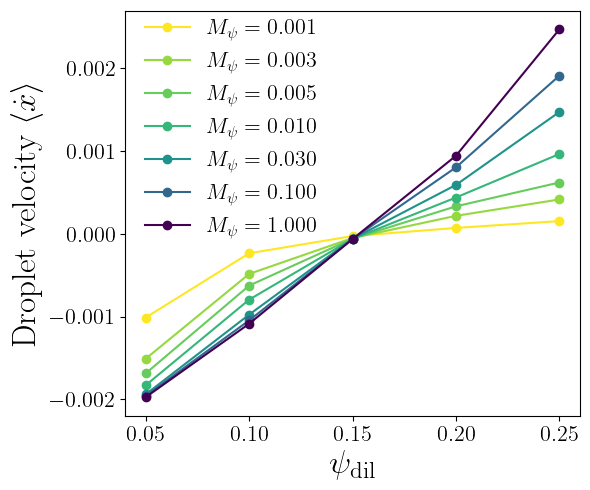

In [68]:
fig, ax = plt.subplots(figsize=(6, 5), tight_layout=True)
for m_id in range(len(M_psi_list)):
    if not M_psi_plot[m_id]:
        continue
    ax.plot(
        psi_g_list,
        xdot_mobile[:, m_id],
        "o-",
        label=f"$M_\\psi={M_psi_list[m_id]:.3f}$",
        color=cmap(norm(np.log10(M_psi_list[m_id]))),
    )
# ax.plot(-cos_theta_list, xdot_mobile, "o-")
ax.set_xlabel(r"$\psi_\mathrm{dil}$")
ax.set_ylabel(r"Droplet velocity $\langle\dot{x}\rangle$")
ax.legend(
    frameon=False, ncol=1, loc="upper left", fontsize=16, bbox_to_anchor=(0, 1.03)
)
# ax.axhline(0, ls="--", color="0.5")
# ax.set_xlim(0, psi_g_list.max())
fig.savefig(output_foldername_summary + "Fig3D.pdf")

In [69]:
# produce colormap in logscale of mobility
from matplotlib import colors as mcolors

norm = mcolors.Normalize(vmin=psi_g_list.min(), vmax=psi_g_list.max())
cmap = plt.cm.viridis
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # only needed for older matplotlib versions

In [70]:
from scipy.optimize import curve_fit

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_87569/2477009977.py:11: SyntaxWarning: invalid escape sequence '\p'
  label=f"$\psi_\mathrm{{dil}}={psi_g_list[psi_g_id]:.2f}$",


fitres for psi_g_id=0: [0.45888914 6.22136811]
fitres for psi_g_id=1: [3.39118283 6.81999276]
fitres for psi_g_id=2: [18.40026047  9.65061758]
fitres for psi_g_id=3: [12.24946389  7.01732085]
fitres for psi_g_id=4: [7.10247294 6.050236  ]


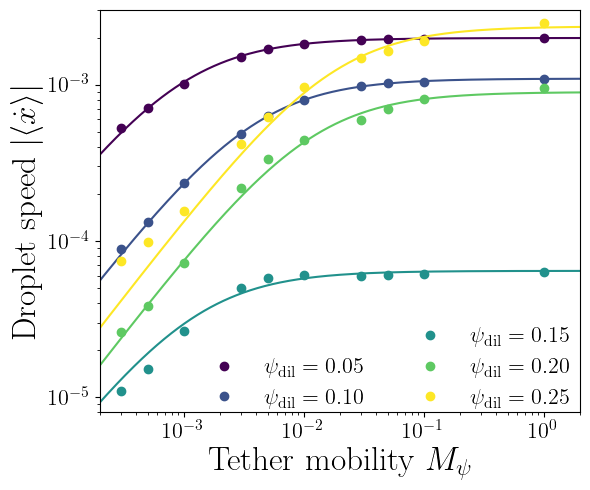

In [71]:
fig, ax = plt.subplots(figsize=(6, 5), tight_layout=True)
fitres_xdot_vs_mpsi_2 = []
fitres_xdot_vs_mpsi_2_err = []
for psi_g_id in range(len(psi_g_list)):
    xdata, ydata = M_psi_list, xdot_mobile[psi_g_id, :]
    ydata = np.abs(ydata)
    ax.plot(
        xdata,
        ydata,
        "o",
        label=f"$\psi_\mathrm{{dil}}={psi_g_list[psi_g_id]:.2f}$",
        color=cmap(norm(psi_g_list[psi_g_id])),
        # clip_on=False,
    )
    fitmask = (~np.isnan(ydata)) & (M_psi_list > 1e-4)
    if np.sum(fitmask) < 2:
        fitres_xdot_vs_mpsi_2.append([np.nan, np.nan])
        continue

    velocity_fun = lambda x, a, b: 1 / (a / x + np.exp(b))
    fitres, pcov = curve_fit(velocity_fun, xdata[fitmask], ydata[fitmask])
    print(f"fitres for psi_g_id={psi_g_id}: {fitres}")
    xfit = np.logspace(-5, 1, 1000)
    yfit = velocity_fun(xfit, *fitres)
    ax.plot(xfit, yfit, "-", color=cmap(norm(psi_g_list[psi_g_id])))
    fitres_xdot_vs_mpsi_2.append(fitres)
    fitres_xdot_vs_mpsi_2_err.append(np.sqrt(np.diag(pcov)))

fitres_xdot_vs_mpsi_2 = np.array(fitres_xdot_vs_mpsi_2)
fitres_xdot_vs_mpsi_2_err = np.array(fitres_xdot_vs_mpsi_2_err)


ax.set_xlabel(r"Tether mobility $M_\psi$")
ax.set_ylabel(r"Droplet speed $|\langle \dot{x} \rangle|$")
ax.set_xlim(xfit.min(), xfit.max())
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(8e-6, 3e-3)
ax.set_xlim(2e-4, 2)
# ax.set_xlim(5e-5, 2)


handles, labels = ax.get_legend_handles_labels()
insert_location = 0
handles.insert(
    insert_location, plt.Line2D([], [], linestyle="None", marker=None, color="none")
)
labels.insert(insert_location, "")  # empty label

ax.legend(
    handles,
    labels,
    frameon=False,
    ncol=2,
    loc="lower right",
    fontsize=16,
    bbox_to_anchor=(1.02, -0.04),
)
fig.savefig(output_foldername_summary + "Fig3E.pdf")

fitres for gamma1/gamma0 vs psi_g(psi_l-psi_g): [ 4.23379785e-01 -1.09816731e-04]


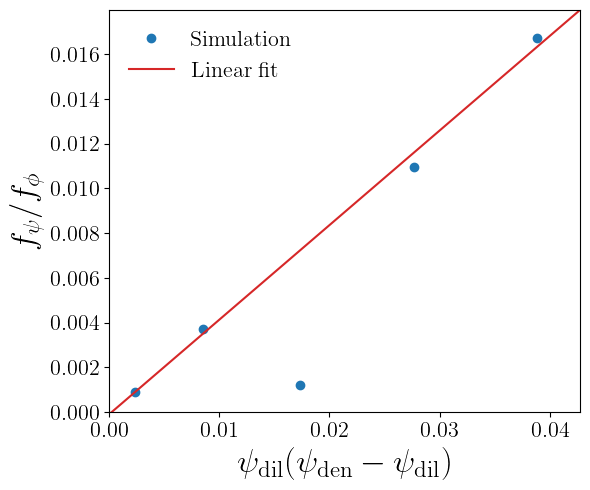

In [72]:
fig, ax = plt.subplots(figsize=(6, 5), tight_layout=True)
xdata, ydata = (
    psi_g_list * (psi_l_list - psi_g_list),
    fitres_xdot_vs_mpsi_2[:, 0] / np.exp(fitres_xdot_vs_mpsi_2[:, 1]),
)
ax.plot(xdata, ydata, "o", label="Simulation")
fit_mask = np.ones(len(xdata), dtype=bool)
fit_mask[2] = False  # ignore the middle point that is off-trend
fitres = np.polyfit(xdata[fit_mask], ydata[fit_mask], 1)
print(f"fitres for gamma1/gamma0 vs psi_g(psi_l-psi_g): {fitres}")
xmesh = np.linspace(0, xdata.max() * 1.1, 100)
ymesh = np.polyval(fitres, xmesh)
ax.plot(
    xmesh,
    ymesh,
    "-",
    label=f"Linear fit",
    color="tab:red",
)

ax.set_xlabel(r"$\psi_\mathrm{dil}(\psi_\mathrm{den}-\psi_\mathrm{dil})$")
ax.set_ylabel(r"$f_\psi/f_\phi$")
ax.set_xlim(0, xmesh[-1])
ax.set_ylim(0, ymesh[-1])
ax.legend(frameon=False)
fig.savefig(output_foldername_summary + "FigS5.pdf")

# Contour plots for typical dynamics

Select snapshots

In [73]:
psi_g_id = 3  # moving up the cone
# psi_g_id = 1  # moving down the cone
m_psi_id = -1

t_trace_mobile = trace_data_mobile[psi_g_id][m_psi_id]["t_trace"]
phi_trace_mobile = data_trace_mobile_all[psi_g_id][m_psi_id]["phi_trace"]
psi_trace_mobile = data_trace_mobile_all[psi_g_id][m_psi_id]["psi_trace"]

t_snaps = np.arange(8) * 800 + 200
snap_ids = [np.abs(t_trace_mobile - t).argmin() for t in t_snaps]
tmax = t_trace_mobile[np.max(snap_ids)]

<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_87569/57320193.py:33: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_ylabel("$\psi$")
/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_87569/57320193.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(
/Users/qiweiyu/miniconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/qiweiyu/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


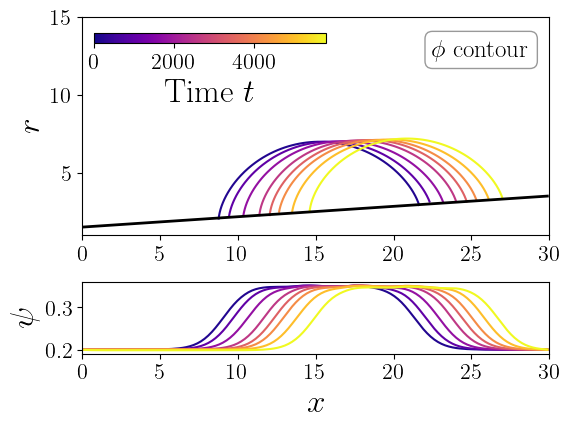

In [74]:
fig = plt.figure(figsize=(5.8, 5), tight_layout=True)

# Create a GridSpec with 2 rows and 1 column
gs = gridspec.GridSpec(
    2, 1, height_ratios=[5, 1]
)  # Adjust height_ratios to make axs[1] shorter

# Create the first subplot
ax1 = fig.add_subplot(gs[0])  # For the first plot (phi)
# Create the second subplot
ax2 = fig.add_subplot(gs[1], sharex=ax1)  # Share x-axis with the first plot

for _ in range(len(snap_ids)):
    ax1.contour(
        PhaseFieldSys.x_c,
        PhaseFieldSys.r_c,
        phi_trace_mobile[snap_ids[_]].T,
        levels=[phi_threshold],
        colors=[plasmamap(t_snaps[_] / tmax)],
        linestyles="-",
        # linewidths=1,
    )
    ax2.plot(
        PhaseFieldSys.x_c,
        psi_trace_mobile[snap_ids[_]],
        color=plasmamap(t_snaps[_] / tmax),
        ls="-",
        # lw=1,
    )

ax1.set_ylabel("$r$")
ax2.set_xlabel("$x$")
ax2.set_ylabel("$\psi$")

ax1.set_xlim(0, flags.Lx)
ax1.set_ylim(flags.Lr1, flags.Lr2)
# ax1.set_ylim(flags.Lr1, 15)

ax1.plot(PhaseFieldSys.x_c, lower_wall(PhaseFieldSys.x_c), "k-", lw=2)

# in panel 1, axx text to inclidate that it is phi contour
ax1.text(
    0.75,
    0.9,
    r"$\phi$ contour",
    transform=ax1.transAxes,
    fontsize=18,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="0.5"),
)

# in panel 1, add an inset inside to show a colorbar for time
ax1_inset = fig.add_axes([0.17, 0.78, 0.4, 0.02])
norm = plt.Normalize(vmin=0, vmax=tmax)
cbar = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=plasmamap),
    cax=ax1_inset,
    orientation="horizontal",
)
cbar.set_label("Time $t$")
ax1.set_aspect(1)
fig.savefig(
    output_foldername_summary
    + f"Fig3A.pdf"
    # + "contour_phi_psi_snapshots"
    # + f"psi_g_{psi_g_list[psi_g_id]:.2f}_m_psi_{M_psi_list[m_psi_id]:.2f}.pdf"
)

Fit contour to circles

In [75]:
snap_id = snap_ids[-1]
phi_plot, psi_plot = phi_trace_mobile[snap_id], psi_trace_mobile[snap_id]

/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_87569/3307229813.py:38: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(fitres_sphere.x[0] - (x_sphere - fitres_sphere.x[1]) ** 2)


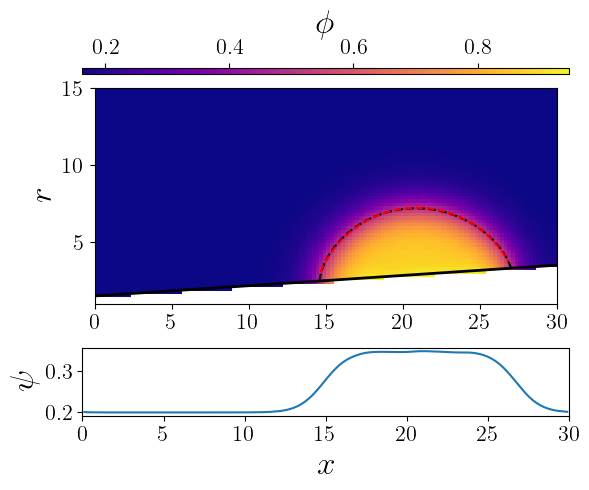

In [76]:
fig, ax1, ax2 = curve_pde.plot_profile(
    phi=phi_plot,
    psi=psi_plot,
    Lx=flags.Lx,
    Lr1=flags.Lr1,
    Lr2=flags.Lr2,
    x_center=PhaseFieldSys.x_c,
    r_center=PhaseFieldSys.r_c,
)
ax1.set_aspect(1)

ax1.plot(PhaseFieldSys.x_c, lower_wall(PhaseFieldSys.x_c), "k-", lw=2)

c = ax1.contour(
    PhaseFieldSys.x_c,
    PhaseFieldSys.r_c,
    phi_plot.T,
    levels=[phi_threshold],
    colors="k",
    linestyles="--",
)

c_path = c.allsegs[0][0]
c_path = c_path[np.argsort(-c_path[:, 1])]


# fit a spherical cap
loss = lambda R0_sqr, x0, r0: np.sum(
    ((c_path[:, 0] - x0) ** 2 + (c_path[:, 1] - r0) ** 2 - R0_sqr) ** 2
)
fitres_sphere = minimize(
    lambda x: loss(x[0], x[1], x[2]),
    x0=[25, flags.Lx / 2, 5],
    method="Nelder-Mead",
)
x_sphere = PhaseFieldSys.x_c.copy()
r_sphere = (
    np.sqrt(fitres_sphere.x[0] - (x_sphere - fitres_sphere.x[1]) ** 2)
    + fitres_sphere.x[2]
)
mask_valid = np.isfinite(r_sphere) & (r_sphere >= lower_wall(x_sphere))
x_sphere, r_sphere = x_sphere[mask_valid], r_sphere[mask_valid]
ax1.plot(
    x_sphere,
    r_sphere,
    "r--",
    label=f"fit: $R_0$={np.sqrt(fitres_sphere.x[0]):.2f}, $z_0$={fitres_sphere.x[1]:.2f}, $r_0$={fitres_sphere.x[2]:.2f}",
)
fig.savefig(
    output_foldername_summary
    + "FigS4B.pdf"
    # + "final_spherical_cap_fit_"
    # + f"psi_g_{psi_g_list[psi_g_id]:.2f}_m_psi_{M_psi_list[m_psi_id]:.2f}.pdf"
)

In [77]:
# compute the total volume of the droplet

v_droplet = np.sum(
    (phi_plot > phi_threshold)
    * PhaseFieldSys.vol_frac
    * PhaseFieldSys.mask_inside
    * PhaseFieldSys.r_c[None, :]  # weight by r in cylindrical coordinates
)
# convert to radius of a sphere
r_droplet = (3 * v_droplet / (4 * np.pi)) ** (1 / 3)
print(f"v_droplet: {v_droplet}, r_droplet: {r_droplet}")

v_droplet: 3597.73046875, r_droplet: 9.505610285496196


# Fig.S4CD: contact angle and preferred radius

In [78]:
cot_theta_mesh = 1 / np.tan(np.arccos(cos_theta_mesh))
psi_g_critical = psi_g_mesh[np.where(cot_theta_mesh > 1e3)[0][0]]
print(f"psi_g_critical: {psi_g_critical}")
r_theory_bare = cot_theta_mesh
r_theory = r_droplet * cot_theta_mesh

psi_g_critical: 0.3006060606060606


/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_87569/1824729358.py:1: RuntimeWarning: divide by zero encountered in divide
  cot_theta_mesh = 1 / np.tan(np.arccos(cos_theta_mesh))


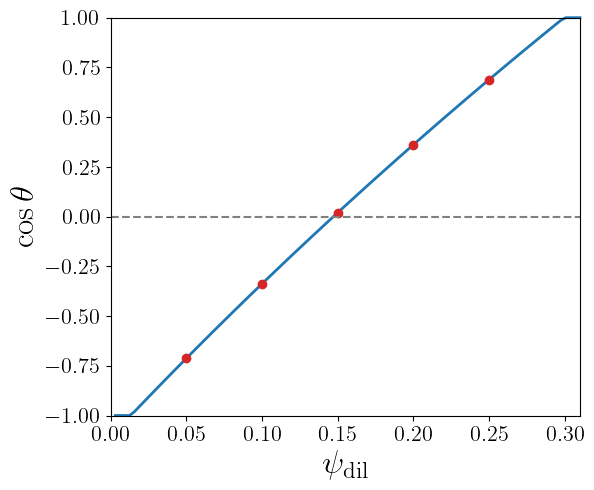

In [79]:
fig, ax = plt.subplots(figsize=(6, 5), tight_layout=True)
ax.plot(psi_g_mesh, cos_theta_mesh, clip_on=False, lw=2)
ax.plot(psi_g_list, cos_theta_list, "o", color="tab:red")
ax.set_xlabel(r"$\psi_\mathrm{dil}$", fontsize=24)
ax.set_ylabel(r"$\cos \theta$", fontsize=24)
ax.set_xlim(0, psi_g_mesh.max())
ax.set_ylim(-1, 1)
ax.axhline(0, ls="--", color="0.5")
fig.savefig(output_foldername_summary + "FigS4C_cos_theta_vs_psi_g.pdf")

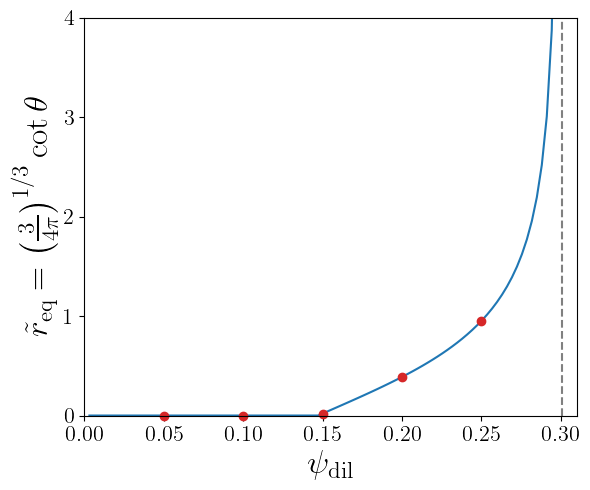

In [80]:
fig, ax = plt.subplots(figsize=(6, 5), tight_layout=True)
ax.plot(psi_g_mesh, np.maximum(0, r_theory_bare), "-", label="theory")
ax.plot(
    psi_g_list,
    np.maximum(0, np.interp(psi_g_list, psi_g_mesh, r_theory_bare)),
    "o",
    label="simulation",
    color="tab:red",
    clip_on=False,
)
ax.axvline(psi_g_critical, ls="--", color="0.5", label=r"$\psi_\mathrm{g,crit}$")
ax.set_ylim(0, 4)
ax.set_xlim(0, psi_g_mesh.max())
ax.set_yticks(np.arange(5))
ax.set_xlabel(r"$\psi_\mathrm{dil}$")
ax.set_ylabel(
    r"$\tilde{r}_\mathrm{eq} = \left(\frac{3}{4\pi}\right)^{1/3} \cot \theta$"
)
fig.savefig(output_foldername_summary + "FigS4D_req_vs_psi_g.pdf")